# Shap on 6 features - embeddings based

Initial run as always to th get the right working folder + One more for imports

In [2]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'p

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


In [3]:
import shap
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput, EmbeddingsManager
from main import parse_config #, Stats, make_dataset, create_embeddings_bacteria, create_embeddings_phages, logger

# from pbi_utils.types import CACHED_EMBEDDINGS_OPTION # bool | Literal["auto"]

## initialization

In [4]:
CONFIG_PATH = "model_configs/best_model_XAI.yaml"
config = parse_config(CONFIG_PATH)
DEVICE = config.device

[DEBUG] [NT2] Using InstaDeepAI default model weights


/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[DEBUG] [NT2] Using InstaDeepAI default model weights
[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[INFO] Configuration loaded from model_configs/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/all/bacteria_df.csv' phages_df='data/perphect-data/all/phages_df.csv' couples_df='data/perphect-data/all-private-oversampled/couples_df.csv', embeddings_dir=data/embeddings, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_fact

### Confighuration
With ability to run only those changes that actually needed

In [5]:
# Raw (pre-PCA) block boundaries in the 18,824-dim flat embedding

BACT_BLOCKS = {
    "bact_NT2":      (0,    1536),
    "bact_MegaDNA":  (1536, 2500),
    "bact_DNABERT2": (2500, 4036),
}
BACT_DIM = 4036

# phage_embedding is shape (14788,): NT2 | MegaDNA | DNABERT2
PHAG_BLOCKS = {
    "phag_NT2":      (0,    1536),
    "phag_MegaDNA":  (1536, 2500),
    "phag_DNABERT2": (2500, 14788),
}
PHAG_DIM = 14788

# Combined block boundaries in the flat (4036 + 14788 = 18824) space
# phage offsets are shifted by BACT_DIM
BLOCKS = {**BACT_BLOCKS,
          **{k: (s + BACT_DIM, e + BACT_DIM) for k, (s, e) in PHAG_BLOCKS.items()}}
BLOCK_NAMES = list(BLOCKS.keys())
N_BLOCKS = len(BLOCK_NAMES)   # 6
TOTAL_DIM = BACT_DIM + PHAG_DIM  # 18824

def tensor_to_numpy(t):
    return t.detach().cpu().numpy()

print("Block definitions (in flat 18824-dim space):")
for name, (s, e) in BLOCKS.items():
    print(f"  {name}: [{s}:{e}] ({e - s} dims)")

Block definitions (in flat 18824-dim space):
  bact_NT2: [0:1536] (1536 dims)
  bact_MegaDNA: [1536:2500] (964 dims)
  bact_DNABERT2: [2500:4036] (1536 dims)
  phag_NT2: [4036:5572] (1536 dims)
  phag_MegaDNA: [5572:6536] (964 dims)
  phag_DNABERT2: [6536:18824] (12288 dims)


In [6]:
# I guess that here should be custom embeddings folder to not mess up OG embeddings
CUSTOM_EMBEDDINGS_FOLDER = "XAI/embeddings"
output_manager = H5pyEmbeddingsManager(CUSTOM_EMBEDDINGS_FOLDER)
#output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from XAI/embeddings


In [7]:
FILTERED_PAIRS = [
    {"id": 788, "bacterium_id": 153, "phage_id": 2014},
    {"id": 939, "bacterium_id": 153, "phage_id": 2153},
    {"id": 2271, "bacterium_id": 1869, "phage_id": 6187},
    {"id": 741, "bacterium_id": 5859, "phage_id": 451},
    {"id": 728, "bacterium_id": 5859, "phage_id": 5924},
    {"id": 768, "bacterium_id": 5859, "phage_id": 5928},
] # first one is the test pair

In [39]:
TEST_PAIR = FILTERED_PAIRS[4]

### Loading the dataset aka meta embeddings

In [9]:
# load option
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
emb_test_data = emb_test_data.reset_index(drop=True)
emb_test_data.head() # embeddings from the test part in the training stage

,id,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,1127,2318,1869,1,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(-0.4400, device='cuda:0'), tensor(0.56..."
1,4505,4095,1869,0,"[tensor(-0.2436, device='cuda:0'), tensor(0.46...","[tensor(0.3543, device='cuda:0'), tensor(-0.05..."
2,7056,5303,5196,0,"[tensor(-0.0618, device='cuda:0'), tensor(0.18...","[tensor(-0.0118, device='cuda:0'), tensor(0.18..."
3,6430,5322,5201,0,"[tensor(-0.1654, device='cuda:0'), tensor(0.29...","[tensor(-0.1430, device='cuda:0'), tensor(0.33..."
4,3605,2246,5859,0,"[tensor(-0.1581, device='cuda:0'), tensor(0.44...","[tensor(-0.1737, device='cuda:0'), tensor(0.38..."


In [11]:
len(emb_test_data['phage_embedding'])

1426

In [12]:
len(emb_test_data['phage_embedding'].iloc[0])

14788

### Loading from the config and appling PCA

In [10]:
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)
#emb_test_data["bacterium_embedding"] = list(torch.from_numpy(pca_bact.transform(emb_test_data["bacterium_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)
#emb_test_data["phage_embedding"] = list(torch.from_numpy(pca_phag.transform(emb_test_data["phage_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore


### Loading model

In [11]:
bacterium_embed_size = 500 #len(emb_test_data["bacterium_embedding"].iloc[0]) # always 500 ???
phage_embed_size = 500 #len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))

/home/pavel.degterev/miniforge3/envs/pbi/lib/python3.10/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


<All keys matched successfully>

## KernelExplainer — 6-Feature Group Masking

**Core idea:** instead of working in the 18,824-dim raw embedding space, we reduce the problem to exactly **6 features** — one per model block. Each feature is a binary on/off switch: 1 = use the real embedding for that block, 0 = replace it with a baseline. `KernelExplainer` then perturbs these 6 switches in all 2^6 = 64 combinations to compute Shapley values.

### Step 2 — Build raw data matrix and baseline

The **baseline** we use is the **column-wise mean** across the background set — the average embedding for each model. *I guess This is statistically sounder than using zeros (which are not a natural point in embedding space).*

If you have training data available, prefer it as the background over test data. 
I didn't and given specifics of the split - it might give the same results (there is same entities of bact. and phages in both sets)

In [12]:
# Bacteria baseline: mean over unique bacterium_id rows
unique_bact = emb_test_data.drop_duplicates(subset="bacterium_id")
baseline_bact = np.median(np.stack([
    tensor_to_numpy(t) for t in unique_bact["bacterium_embedding"]
]), axis=0)  # (4036,)

# Phage baseline: mean over unique phage_id rows
unique_phag = emb_test_data.drop_duplicates(subset="phage_id")
baseline_phag = np.median(np.stack([
    tensor_to_numpy(t) for t in unique_phag["phage_embedding"]
]), axis=0)  # (14788,)

# Combined baseline in flat space
baseline_full = np.concatenate([baseline_bact, baseline_phag])  # (18824,)

# ── Full data matrix ───────────────────────────────────────────────────────────
X_raw = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
    for _, row in emb_test_data.iterrows()
])  # (N, 18824)

print(f"X_raw shape:    {X_raw.shape}")
print(f"baseline_bact shape:  {baseline_bact.shape}")
print(f"baseline_phag shape: {baseline_phag.shape}")
print(f"baseline_full shape: {baseline_full.shape}")
print(f"Unique bacteria: {len(unique_bact)}, unique phage: {len(unique_phag)}, pairs: {len(emb_test_data)}")

X_raw shape:    (1426, 18824)
baseline_bact shape:  (4036,)
baseline_phag shape: (14788,)
baseline_full shape: (18824,)
Unique bacteria: 166, unique phage: 860, pairs: 1426


### Baseline crosscheck for phage & bacteria

In [13]:
def predict_fn(X):
    bact_raw  = X[:, :BACT_DIM]
    phage_raw = X[:, BACT_DIM:]
    bact_pca  = pca_bact.transform(bact_raw)
    phage_pca = pca_phag.transform(phage_raw)
    bact_t  = torch.from_numpy(bact_pca).float().to(DEVICE)
    phage_t = torch.from_numpy(phage_pca).float().to(DEVICE)
    model.eval(); model.to(DEVICE)
    with torch.no_grad():
        logits = model(bact_t, phage_t)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs.detach().cpu().numpy()


row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]

test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])

# What does the model predict when one organism is pure baseline (mean)?
bact_mean_row = np.concatenate([baseline_bact, tensor_to_numpy(row["phage_embedding"])])
phag_mean_row = np.concatenate([tensor_to_numpy(row["bacterium_embedding"]), baseline_phag])
both_mean_row = baseline_full.copy()

print(f'Cross check for bacteria #{TEST_PAIR["bacterium_id"]} & phage #{TEST_PAIR["phage_id"]} \n(pair id {TEST_PAIR["id"]})\n')
print(f"Real pair prediction:        {predict_fn(test_row)[0]:.4f}")
print(f"Phage real, bact=mean:       {predict_fn(bact_mean_row.reshape(1,-1))[0]:.4f}")
print(f"Bact real, phage=mean:       {predict_fn(phag_mean_row.reshape(1,-1))[0]:.4f}")
print(f"Both mean (baseline):        {predict_fn(both_mean_row.reshape(1,-1))[0]:.4f}")

Cross check for bacteria #153 & phage #2153 
(pair id 939)

Real pair prediction:        0.9998
Phage real, bact=mean:       0.9994
Bact real, phage=mean:       0.0200
Both mean (baseline):        0.2700


### Step 3 — The 6-dimensional representation

We now represent each sample as a vector of **6 ones**: `[1, 1, 1, 1, 1, 1]`. Each entry means 'this block is present (not masked)'. SHAP will create versions with 0s (block absent = replaced by baseline) and measure how the prediction changes.

The key function is `expand_6d_to_full(x_6d, X_full_row)` which takes a 6-dim mask vector and the real 18,824-dim embedding, and returns the 18,824-dim vector where absent blocks are filled from the baseline.

In [14]:
def expand_6d_to_full(x_6d: np.ndarray, x_full_row: np.ndarray) -> np.ndarray:
    """
    Expand a 6-dim mask vector back into the full 18,824-dim embedding.

    x_6d      : (6,) array of values in [0, 1].
                  1.0  = use the real embedding for this block (block present).
                  0.0  = replace with baseline (block absent).
                  0..1 = linear interpolation between baseline and real.
    x_full_row: (18824,) the real embedding for this sample.
    Returns   : (18824,) the mixed embedding.
    """
    out = baseline_full.copy()
    for i, name in enumerate(BLOCK_NAMES):
        s, e = BLOCKS[name]
        alpha = float(x_6d[i])  # 1.0 = real, 0.0 = baseline
        #out[s:e] = alpha * x_full_row[s:e] + (1 - alpha) * baseline_full[s:e]
        out[s:e] = alpha * x_full_row[s:e]
    return out

# The reference 6-dim input: all blocks present
X_6d = np.ones((len(X_raw), N_BLOCKS), dtype=np.float64)
print(f'X_6d shape: {X_6d.shape}')  # (N, 6)

# Background for KernelExplainer: all-ones (all blocks present = natural state)
# We use the mean of X_6d which is just ones, but passing the actual matrix
# allows KernelExplainer to weight by frequency if samples vary.
background_6d = np.zeros((1, N_BLOCKS), dtype=np.float64)  # single reference point
print(f'Background 6d shape: {background_6d.shape}')


X_6d shape: (1426, 6)
Background 6d shape: (1, 6)


### Step 4 — Wrapper prediction function

SHAP will call `predict_6d(x_6d_batch)` with arrays of shape `(batch, 6)` where each row has some entries set to 0 (block absent) or 1 (block present). The wrapper:
1. Expands each 6-dim row back to 18,824 dims using `expand_6d_to_full`
2. Splits into bacteria/phage halves
3. Applies the fitted PCA
4. Runs the classifier

The `_current_row` variable is set before each explanation call so the wrapper knows which real embedding to use for the 'present' blocks.

In [15]:
# We use a mutable container to pass the current real embedding into the closure.
# This is needed because KernelExplainer only passes the 6-dim mask, not the
# original 18,824-dim vector.
_current_row = {'x_full': None}

BACT_DIM = sum(e - s for s, e in
               [BLOCKS[k] for k in ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2']])
# = 4036

def predict_6d(x_6d_batch: np.ndarray) -> np.ndarray:
    """
    Input : (batch, 6) — binary/fractional mask for each model block.
    Output: (batch,)   — P(interaction == 1).
    """
    x_full_row = _current_row['x_full']  # (18824,) real embedding
    # Expand each 6-dim mask to the full 18,824-dim mixed embedding
    full_batch = np.stack([
        expand_6d_to_full(x_6d_batch[i], x_full_row)
        for i in range(len(x_6d_batch))
    ])  # (batch, 18824)

    bact_raw  = full_batch[:, :BACT_DIM].astype(np.float64)
    phage_raw = full_batch[:, BACT_DIM:].astype(np.float64)

    bact_pca  = pca_bact.transform(bact_raw)
    phage_pca = pca_phag.transform(phage_raw)

    bact_t  = torch.from_numpy(bact_pca.astype(np.float32)).to(DEVICE)
    phage_t = torch.from_numpy(phage_pca.astype(np.float32)).to(DEVICE)

    model.eval()
    model.to(DEVICE)
    with torch.no_grad():
        logits = model(bact_t, phage_t)               # (batch, 2)
        probs  = torch.softmax(logits, dim=1)[:, 1]  # P(class=1)
    return probs.cpu().numpy()

# Sanity-check with all blocks present (should match pipeline prediction)
_current_row['x_full'] = X_raw[0]
test = predict_6d(np.ones((1, N_BLOCKS)))
print(f'Sanity-check (all blocks present): P(interaction=1) = {test[0]:.6f}')

# Sanity-check with all blocks absent (should give baseline/random-ish prediction)
test_absent = predict_6d(np.zeros((1, N_BLOCKS)))
print(f'Sanity-check (all blocks absent):  P(interaction=1) = {test_absent[0]:.6f}')


Sanity-check (all blocks present): P(interaction=1) = 0.998844
Sanity-check (all blocks absent):  P(interaction=1) = 0.000000


### Step 6 — Build KernelExplainer & Explain a single pair

`shap.KernelExplainer(f, background)` takes:
- `f`: the prediction function that accepts `(batch, 6)` inputs
- `background`: the reference point when a feature is 'absent'

Here our background is `[[1,1,1,1,1,1]]` — the 'all present' state. This means SHAP measures: *how much does the prediction change when I remove block X, relative to having all blocks present?*

For each sample, we set `_current_row['x_full']` to the real 18,824-dim embedding of that sample, then call the explainer on the 6-dim all-ones input. SHAP will internally set some entries to 0 and re-run `predict_6d` each time.

In [40]:
row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]

test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])

# Set the real embedding for this sample
_current_row['x_full'] = test_row[0]

# If explainer will be created before _current_row - it will contain wrong global variable
kernel_explainer = shap.KernelExplainer(predict_6d, background_6d)

# Explain: input is all-ones (all blocks present for this sample)
shap_values_single = kernel_explainer.shap_values(
    np.ones((1, N_BLOCKS)),
    nsamples='auto',  # exhaustive for 6 features
    silent=True
)
# shap_values_single shape: (1, 6)

print('Block-level SHAP contributions (KernelExplainer):\n')
block_contribs_all = {}
for i, name in enumerate(BLOCK_NAMES):
    contrib = float(shap_values_single[0][i])
    block_contribs_all[name] = contrib
    print(f'  {name:<20s}: {contrib:+.6f}')

base_val   = float(kernel_explainer.expected_value)
model_pred = float(predict_6d(np.ones((1, N_BLOCKS)))[0])
shap_sum   = sum(block_contribs_all.values())
print(f'\nBaseline (expected value) : {base_val:.6f}')
print(f'Sum of contributions      : {shap_sum:+.6f}')
print(f'Baseline + sum (approx)   : {base_val + shap_sum:.6f}')
print(f'Model output P(class=1)   : {model_pred:.6f}')

Block-level SHAP contributions (KernelExplainer):

  bact_NT2            : +0.303746
  bact_MegaDNA        : +0.098705
  bact_DNABERT2       : +0.254929
  phag_NT2            : +0.303746
  phag_MegaDNA        : +0.093530
  phag_DNABERT2       : -0.054663

Baseline (expected value) : 0.000000
Sum of contributions      : +0.999994
Baseline + sum (approx)   : 0.999994
Model output P(class=1)   : 0.999994


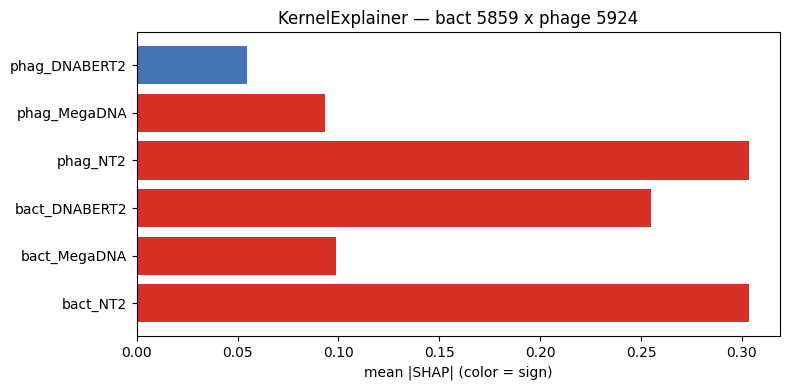

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(block_contribs_all.keys())
raw    = list(block_contribs_all.values())

values = [abs(v) for v in raw]
colors = ['#d73027' if v > 0 else '#4575b4' for v in raw]

ax.barh(names, values, color=colors)
ax.set_xlabel('mean |SHAP| (color = sign)')
ax.set_title(
    f'KernelExplainer — bact {row["bacterium_id"]} x phage {row["phage_id"]}'
)
plt.tight_layout()
plt.savefig('XAI/kernel_shap_single_abs.png', dpi=150)
plt.show()

In [29]:
bact_zero_row = np.concatenate([np.zeros(BACT_DIM), tensor_to_numpy(row["phage_embedding"])])
phag_zero_row = np.concatenate([tensor_to_numpy(row["bacterium_embedding"]), np.zeros(PHAG_DIM)])
both_zero_row = np.zeros(BACT_DIM + PHAG_DIM)

print(f'Cross check for bacteria #{TEST_PAIR["bacterium_id"]} & phage #{TEST_PAIR["phage_id"]} \n(pair id {TEST_PAIR["id"]})\n')
print(f"Real pair prediction:        {predict_fn(test_row)[0]:.4f}")
print(f"Phage real, bact=zeros:      {predict_fn(bact_zero_row.reshape(1,-1))[0]:.4f}")
print(f"Bact real, phage=zeros:      {predict_fn(phag_zero_row.reshape(1,-1))[0]:.4f}")
print(f"Both zeros:                  {predict_fn(both_zero_row.reshape(1,-1))[0]:.4f}")

Cross check for bacteria #153 & phage #2153 
(pair id 939)

Real pair prediction:        0.9998
Phage real, bact=zeros:      0.0000
Bact real, phage=zeros:      0.0000
Both zeros:                  0.0000


### Step 7 — Explain multiple pairs

Because each call to `predict_6d` needs the real embedding of the current sample, we loop over rows and collect results into a DataFrame. This is different from PartitionExplainer which can vectorise across the batch internally — here we must set `_current_row` before each call.

In [18]:
n_rows = min(1000, len(X_raw))  # Increase after validating runtime
all_contribs = []

for i in range(n_rows):
    _current_row['x_full'] = X_raw[i]
    sv = kernel_explainer.shap_values(
        X_6d[i:i + 1],
        nsamples='auto',
        silent=True
    )
    row_contribs = {name: float(sv[0][j]) for j, name in enumerate(BLOCK_NAMES)}
    # Attach pair identifiers
    row_contribs['bacterium_id'] = int(emb_test_data.iloc[i]['bacterium_id'])
    row_contribs['phage_id']      = int(emb_test_data.iloc[i]['phage_id'])
    row_contribs['true_label']    = int(emb_test_data.iloc[i]['interaction_type'])
    row_contribs['pred_prob']     = float(predict_6d(X_6d[i:i + 1])[0])
    all_contribs.append(row_contribs)

contrib_df_all = pd.DataFrame(all_contribs)
display(contrib_df_all)

print('\nMean absolute SHAP contribution per block:')
display(
    contrib_df_all[BLOCK_NAMES].abs().mean().sort_values(ascending=False).rename('mean |SHAP|')
)


,bact_NT2,bact_MegaDNA,bact_DNABERT2,phag_NT2,phag_MegaDNA,phag_DNABERT2,bacterium_id,phage_id,true_label,pred_prob
0,0.200167,0.199391,0.199443,0.200089,0.200167,-4.119682e-04,1869,2318,1,9.988437e-01
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1869,4095,0,4.646981e-13
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,5196,5303,0,4.397029e-10
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,5201,5322,0,7.549225e-10
4,0.000523,0.000484,0.000523,0.000523,-0.000997,-1.056593e-03,5859,2246,0,2.378834e-07
...,...,...,...,...,...,...,...,...,...,...
995,0.014520,0.014491,0.014517,0.014520,-0.027596,-3.045149e-02,5859,6034,0,8.425533e-09
996,0.019922,0.019924,0.019923,-0.023579,-0.022585,-1.360495e-02,507,5216,0,1.824881e-08
997,0.243339,0.136039,0.222796,0.243339,0.209515,-5.506014e-02,5859,3427,1,9.999672e-01
998,0.128046,0.115916,0.072559,-0.027793,-0.263781,-1.692283e-02,5703,3722,1,8.025018e-03



Mean absolute SHAP contribution per block:


bact_NT2         0.076348
phag_NT2         0.071774
bact_DNABERT2    0.056416
phag_MegaDNA     0.051554
bact_MegaDNA     0.044894
phag_DNABERT2    0.023173
Name: mean |SHAP|, dtype: float64

### Step 8 — Visualisation

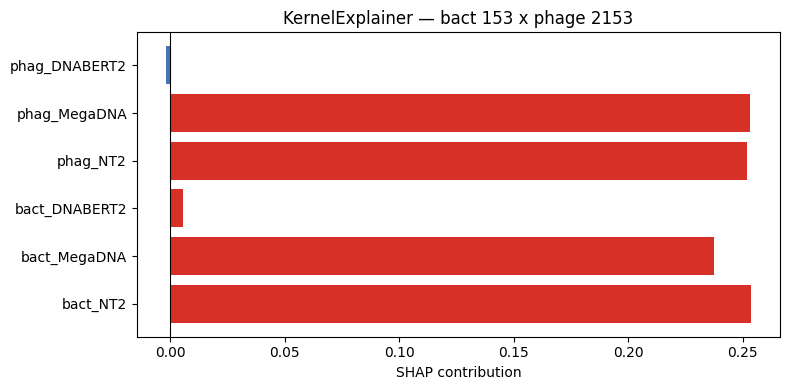

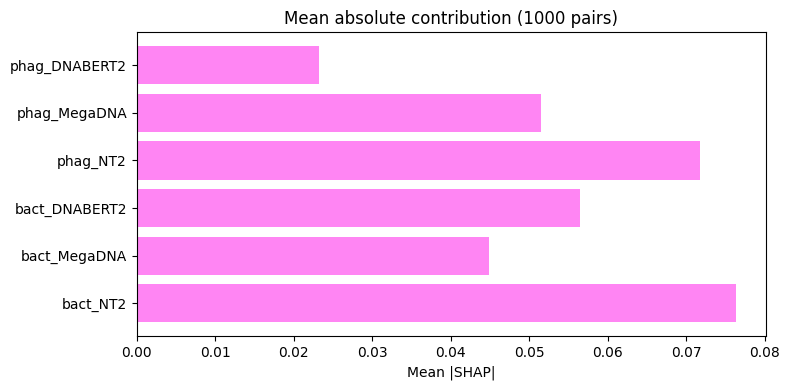

In [19]:
import os; os.makedirs('XAI', exist_ok=True)

# ── Single-pair waterfall-style bar chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(block_contribs_all.keys())
values = list(block_contribs_all.values())
colors = ['#d73027' if v > 0 else '#4575b4' for v in values]

ax.barh(names, values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP contribution')
row0 = row
ax.set_title(
    f'KernelExplainer — bact {row0["bacterium_id"]} x phage {row0["phage_id"]}'
)
plt.tight_layout()
plt.savefig('XAI/kernel_shap_single.png', dpi=150)
plt.show()

# ── Mean absolute contribution across all explained pairs ──────────────
mean_abs = contrib_df_all[BLOCK_NAMES].abs().mean()#.sort_values(ascending=False)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.barh(mean_abs.index, mean_abs.values, color="#FF85F3")
ax2.set_xlabel('Mean |SHAP|')
ax2.set_title(f'Mean absolute contribution ({n_rows} pairs)')
plt.tight_layout()
plt.savefig('XAI/kernel_shap_mean.png', dpi=150)
plt.show()


# frozen Bacteria

In [66]:
BLOCK_NAMES_PHAGE = ['phag_NT2', 'phag_MegaDNA', 'phag_DNABERT2']

def predict_phage_3d(x_3d_batch: np.ndarray) -> np.ndarray:
    """Bacteria frozen at 1, SHAP permutes phage [idx 3,4,5]."""
    n = x_3d_batch.shape[0]
    x_6d = np.empty((n, 6), dtype=x_3d_batch.dtype)
    x_6d[:, 0:3] = 1.0           # bacteria always real
    x_6d[:, 3:6] = x_3d_batch    # phage free
    return predict_6d(x_6d)

In [67]:
row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]

test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])

# Set the real embedding for this sample
_current_row['x_full'] = test_row[0]

kernel_explainer_phage = shap.KernelExplainer(predict_phage_3d, np.zeros((1, 3)))

# Explain: input is all-ones (all blocks present for this sample)
shap_values_single = kernel_explainer_phage.shap_values(
    np.ones((1, len(BLOCK_NAMES_PHAGE))),
    nsamples='auto',  # exhaustive for 6 features
    silent=True
)
# shap_values_single shape: (1, 6)

print(f'Block-level SHAP contributions (pair id {TEST_PAIR["id"]}):\n')
block_contribs = {}
for i, name in enumerate(BLOCK_NAMES_PHAGE):
    contrib = float(shap_values_single[0][i])
    block_contribs[name] = contrib
    print(f'  {name:<20s}: {contrib:+.6f}')

base_val   = float(kernel_explainer.expected_value)
model_pred = float(predict_6d(np.ones((1, N_BLOCKS)))[0])
shap_sum   = sum(block_contribs.values())
print()
print(f'Baseline (expected value) : {base_val:.6f}')
print(f'Sum of contributions      : {shap_sum:+.6f}')
print(f'Baseline + sum (approx)   : {base_val + shap_sum:.6f}')
print(f'Model output P(class=1)   : {model_pred:.6f}')

Block-level SHAP contributions (pair id 788):

  phag_NT2            : +0.241868
  phag_MegaDNA        : +0.319470
  phag_DNABERT2       : +0.416022

Baseline (expected value) : 0.827142
Sum of contributions      : +0.977360
Baseline + sum (approx)   : 1.804502
Model output P(class=1)   : 0.999701


In [68]:
target_bact_id = TEST_PAIR["bacterium_id"]

bact_indices = emb_test_data.index[
    emb_test_data["bacterium_id"] == target_bact_id
].tolist()

n_rows = min(1000, len(bact_indices))

all_contribs = []

for k in range(n_rows):
    i = bact_indices[k]

    _current_row['x_full'] = X_raw[i]
    x_phage_i = X_6d[i, 3:6].reshape(1, 3)

    sv = kernel_explainer_phage.shap_values(
        x_phage_i,
        nsamples='auto',
        l1_reg=0,
        silent=True
    )
    row_contribs = {name: float(sv[0][j]) for j, name in enumerate(BLOCK_NAMES_PHAGE)}
    # Attach pair identifiers
    row_contribs['bacterium_id'] = int(emb_test_data.iloc[i]['bacterium_id'])
    row_contribs['phage_id']      = int(emb_test_data.iloc[i]['phage_id'])
    row_contribs['true_label']    = int(emb_test_data.iloc[i]['interaction_type'])
    row_contribs['pred_prob']     = float(predict_6d(X_6d[i:i + 1])[0])
    all_contribs.append(row_contribs)

contrib_df = pd.DataFrame(all_contribs)
display(contrib_df)

print(f"Using {n_rows} rows for bacterium_id = {target_bact_id}.")
print(f'Mean absolute SHAP contribution per block (KernelExplainer):')
display(
    contrib_df[BLOCK_NAMES_PHAGE].abs().mean().sort_values(ascending=False).rename('mean |SHAP|')
)


,phag_NT2,phag_MegaDNA,phag_DNABERT2,bacterium_id,phage_id,true_label,pred_prob
0,0.454418,0.449024,0.074217,153,2220,1,9.999990e-01
1,0.364474,0.355256,0.257926,153,3391,1,9.999963e-01
2,-0.032731,-0.410408,0.475651,153,3564,1,5.485287e-02
3,-0.663001,0.319667,0.321018,153,2055,0,2.459474e-05
4,0.442017,0.413291,0.122255,153,3623,1,9.999030e-01
5,0.470716,0.488462,0.018210,153,1982,1,9.997275e-01
6,0.429565,0.117853,0.430228,153,2375,1,9.999862e-01
7,-0.007872,-0.005718,-0.008745,153,2101,0,5.079065e-06
8,0.398200,0.398762,0.180679,153,3406,1,9.999816e-01
9,-0.145068,0.267834,-0.145106,153,3928,0,2.969320e-08


Using 56 rows for bacterium_id = 153.
Mean absolute SHAP contribution per block (KernelExplainer):


phag_NT2         0.291488
phag_MegaDNA     0.208553
phag_DNABERT2    0.171524
Name: mean |SHAP|, dtype: float64

# frozen Phage

In [63]:
BLOCK_NAMES_BACT  = ['bact_NT2', 'bact_MegaDNA', 'bact_DNABERT2']

def predict_bact_3d(x_3d_batch: np.ndarray) -> np.ndarray:
    """Phage frozen at 1, SHAP permutes bacteria [idx 0,1,2]."""
    n = x_3d_batch.shape[0]
    x_6d = np.empty((n, 6), dtype=x_3d_batch.dtype)
    x_6d[:, 0:3] = x_3d_batch    # bacteria free
    x_6d[:, 3:6] = 1.0           # phage always real
    return predict_6d(x_6d)

In [64]:
row = emb_test_data.loc[emb_test_data["id"] == TEST_PAIR["id"]].iloc[0]


test_row = np.stack([
    np.concatenate([
        tensor_to_numpy(row["bacterium_embedding"]),
        tensor_to_numpy(row["phage_embedding"]),
    ])
])

# Set the real embedding for this sample
_current_row['x_full'] = test_row[0]

kernel_explainer_bact = shap.KernelExplainer(predict_bact_3d, np.zeros((1, 3)))

# Explain: input is all-ones (all blocks present for this sample)
shap_values_single = kernel_explainer_bact.shap_values(
    np.ones((1, len(BLOCK_NAMES_BACT))),
    nsamples='auto',  # exhaustive for 6 features
    silent=True
)
# shap_values_single shape: (1, 6)

print(f'Block-level SHAP contributions (pair id {TEST_PAIR["id"]}):')
block_contribs = {}
for i, name in enumerate(BLOCK_NAMES_BACT):
    contrib = float(shap_values_single[0][i])
    block_contribs[name] = contrib
    print(f'  {name:<20s}: {contrib:+.6f}')

base_val   = float(kernel_explainer.expected_value)
model_pred = float(predict_6d(np.ones((1, N_BLOCKS)))[0])
shap_sum   = sum(block_contribs.values())
print()
print(f'Baseline (expected value) : {base_val:.6f}')
print(f'Sum of contributions      : {shap_sum:+.6f}')
print(f'Baseline + sum (approx)   : {base_val + shap_sum:.6f}')
print(f'Model output P(class=1)   : {model_pred:.6f}')

Block-level SHAP contributions (pair id 788):
  bact_NT2            : +0.014703
  bact_MegaDNA        : -0.007482
  bact_DNABERT2       : -0.006600

Baseline (expected value) : 0.827142
Sum of contributions      : +0.000621
Baseline + sum (approx)   : 0.827763
Model output P(class=1)   : 0.999701


In [65]:
target_bact_id = TEST_PAIR["phage_id"]

phage_indices = emb_test_data.index[
    emb_test_data["phage_id"] == target_bact_id
].tolist()

n_rows = min(1000, len(phage_indices))

all_contribs = []

for k in range(n_rows):
    i = phage_indices[k]

    _current_row['x_full'] = X_raw[i]
    x_phage_i = X_6d[i, 3:6].reshape(1, 3)

    sv = kernel_explainer_bact.shap_values(
        x_phage_i,
        nsamples='auto',
        l1_reg=0,
        silent=True
    )
    row_contribs = {name: float(sv[0][j]) for j, name in enumerate(BLOCK_NAMES_BACT)}
    # Attach pair identifiers
    row_contribs['bacterium_id'] = int(emb_test_data.iloc[i]['bacterium_id'])
    row_contribs['phage_id']      = int(emb_test_data.iloc[i]['phage_id'])
    row_contribs['true_label']    = int(emb_test_data.iloc[i]['interaction_type'])
    row_contribs['pred_prob']     = float(predict_6d(X_6d[i:i + 1])[0])
    all_contribs.append(row_contribs)

contrib_df = pd.DataFrame(all_contribs)
display(contrib_df)

print(f"Using {n_rows} rows for bacterium_id = {target_bact_id}.")
print(f'Mean absolute SHAP contribution per block (KernelExplainer):')
display(
    contrib_df[BLOCK_NAMES_BACT].abs().mean().sort_values(ascending=False).rename('mean |SHAP|')
)


,bact_NT2,bact_MegaDNA,bact_DNABERT2,bacterium_id,phage_id,true_label,pred_prob
0,0.014703,-0.007482,-0.0066,153,2014,1,0.999701


Using 1 rows for bacterium_id = 2014.
Mean absolute SHAP contribution per block (KernelExplainer):


bact_NT2         0.014703
bact_MegaDNA     0.007482
bact_DNABERT2    0.006600
Name: mean |SHAP|, dtype: float64